# 🤖 ResolveFlow AI — Multi-Agent Customer Support Triage

**LangGraph + Pinecone + Gemini | Research PoC**

---

## Project Overview

This notebook implements an AI-powered dispute triage pipeline for C2C marketplace platforms, where buyer, seller, and platform contexts each require different escalation logic and resolution paths.

Instead of routing every query directly to an LLM, the system uses **5 specialized agents** to assess, respond, and act on each issue. Every decision is grounded in retrieved knowledge and logged back as institutional memory.

---

## Pipeline Architecture

```text
User Query
     ↓
┌─────────────────────────────────────────┐
│         AGENT 1: RETRIEVAL              │
│  Embeds query                           │
│  Searches support-docs namespace        │
│  Searches action-logs namespace         │
└─────────────────────────────────────────┘
     ↓
┌─────────────────────────────────────────┐
│         AGENT 2: EVALUATION             │
│  Severity score: 1–5                    │
│  Sentiment classification               │
│  Issue type classification              │
│  Escalation flag                        │
│  Trust & Safety flag                    │
└─────────────────────────────────────────┘
     ↓
route_after_evaluation()

     ├── system_error / trust_safety
     │        ↓
     │   HUMAN REVIEW
     │        ↓
     │      AUDIT
     │        ↓
     │       END
     │
     └── normal
              ↓
┌─────────────────────────────────────────┐
│         AGENT 3: RESPONSE               │
│  Generates customer-facing answer       │
│  Adjusts tone based on severity         │
│  Adjusts tone based on sentiment        │
└─────────────────────────────────────────┘
     ↓
route_after_response()

     ├── severity ≥ 4
     │        ↓
     │   SUPERVISOR
     │        ↓
     │      AUDIT
     │        ↓
     │       END
     │
     └── severity < 4
              ↓
            AUDIT
              ↓
             END
```

---

## Evaluation Framework

| Metric               | Description                                              | Target         |
| -------------------- | -------------------------------------------------------- | -------------- |
| Severity MAE         | Average error versus human-labeled severity ground truth | < 0.5          |
| Escalation Precision | Accuracy of issues flagged for escalation                | High precision |
| Escalation Recall    | Ability to capture truly escalatable cases               | High recall    |

---

## Tech Stack

| Component            | Tool                            |
| -------------------- | ------------------------------- |
| Vector Database      | Pinecone                        |
| Vector Namespaces    | `support-docs`, `action-logs`   |
| LLM                  | Gemini 2.5 Flash via LangChain  |
| Embeddings           | `gemini-embedding-001`          |
| Embedding Dimensions | 3,072                           |
| Agent Orchestration  | LangGraph `StateGraph`          |
| Memory               | LangGraph `MemorySaver`         |
| Dataset              | Bitext Customer Support Dataset |
| Dataset Size         | 26,872 rows                     |
| Environment          | Google Colab                    |


# Section 0: Environment Setup

In [1]:
!pip install -q datasets pinecone google-generativeai tqdm \
         langgraph langchain-google-genai langchain-core pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 19.6 MB/s eta 0:00:00


In [2]:
import os, json, time, uuid, datetime
import pandas as pd
from typing import TypedDict, List, Dict, Any, Annotated
from google.colab import userdata

import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from pinecone import Pinecone, ServerlessSpec
from datasets import load_dataset
from tqdm import tqdm

print("✅ All libraries imported")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ All libraries imported


In [3]:
PINECONE_API_KEY = userdata.get("PINECONE_API_KEY")
GEMINI_API_KEY   = userdata.get("API_Agent")

genai.configure(api_key=GEMINI_API_KEY)
pc = Pinecone(api_key=PINECONE_API_KEY)

print("✅ API keys loaded")
print(f"   Pinecone client: {type(pc)}")

✅ API keys loaded
   Pinecone client: <class 'pinecone._client.Pinecone'>


## LLM & Structured Output Setup

In [ ]:
lc_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    google_api_key=GEMINI_API_KEY
)

# ── Pydantic schemas ──────────────────────────────────────────
class EvaluationSchema(BaseModel):
    severity_score : int  = Field(ge=1, le=5, description="1=routine to 5=critical")
    severity_label : str  = Field(description="routine|minor|moderate|serious|critical")
    sentiment      : str  = Field(description="neutral|frustrated|angry")
    issue_type     : str  = Field(description="billing|delivery|account|refund|dispute|fraud|other")
    repeat_issue   : bool
    escalate       : bool
    trust_safety   : bool = Field(default=False, description="Flag for Trust & Safety team")
    reasoning      : str  = Field(description="max 10 words explaining the score")
    suggested_tone : str  = Field(description="professional|empathetic|urgent")

class SupervisorSchema(BaseModel):
    escalated      : bool
    action         : str = Field(description="compensate|escalate_management|escalate_rca|assign_human|monitor|none")
    compensation   : str = Field(description="none|10%_discount|20%_discount|full_refund|service_credit|free_month")
    assigned_to    : str = Field(description="none|human_agent|senior_manager|rca_team|trust_safety_team|legal_team")
    priority       : str = Field(description="normal|high|urgent")
    internal_notes : str = Field(description="max 10 words")

eval_llm       = lc_llm.with_structured_output(EvaluationSchema)
supervisor_llm = lc_llm.with_structured_output(SupervisorSchema)

print("✅ LLMs and schemas defined")

# Section 1: Vector DB Setup

## Load Dataset

In [ ]:
print("Loading Bitext dataset...")
dataset    = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
train_data = dataset["train"]
df         = train_data.to_pandas()
df_subset  = df.sample(n=1000, random_state=42).reset_index(drop=True)

print(f"\n✅ Dataset loaded")
print(f"   Total rows    : {len(df):,}")
print(f"   Subset rows   : {len(df_subset)}")
print(f"   Unique intents: {df_subset['intent'].nunique()}")
print(f"   Columns       : {df.columns.tolist()}")

## Embedding Functions

In [ ]:
test_emb      = genai.embed_content(
    model="models/gemini-embedding-001",
    content="test",
    task_type="retrieval_document"
)
EMBEDDING_DIM = len(test_emb["embedding"])
print(f"✅ Embedding dimension confirmed: {EMBEDDING_DIM}")

def embed_text(text: str) -> list[float]:
    """Embed a document for storage."""
    return genai.embed_content(
        model="models/gemini-embedding-001",
        content=text,
        task_type="retrieval_document"
    )["embedding"]

def embed_query(text: str) -> list[float]:
    """Embed a user query for search."""
    return genai.embed_content(
        model="models/gemini-embedding-001",
        content=text,
        task_type="retrieval_query"
    )["embedding"]

print("✅ Embedding functions defined")

## Create Pinecone Index

In [ ]:
INDEX_NAME     = "customer-support-rag"
NAMESPACE_DOCS = "support-docs"
NAMESPACE_LOGS = "action-logs"

existing = [idx.name for idx in pc.list_indexes()]
if INDEX_NAME not in existing:
    pc.create_index(
        name=INDEX_NAME,
        dimension=EMBEDDING_DIM,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1")
    )
    print(f"✅ Index '{INDEX_NAME}' created")
else:
    print(f"✅ Index '{INDEX_NAME}' already exists")

index = pc.Index(INDEX_NAME)
print(f"   Stats: {index.describe_index_stats()}")

In [ ]:
# ── Upsert support-docs (skip if already populated) ──────────
stats = index.describe_index_stats()
ns    = stats.get("namespaces", {})

if NAMESPACE_DOCS in ns and ns[NAMESPACE_DOCS].get("vector_count", 0) >= 1000:
    print(f"✅ '{NAMESPACE_DOCS}' already populated — skipping upsert")
else:
    print(f"Upserting 1000 rows into '{NAMESPACE_DOCS}'...")
    BATCH_SIZE = 50
    for batch_start in tqdm(range(0, len(df_subset), BATCH_SIZE)):
        batch   = df_subset.iloc[batch_start: batch_start + BATCH_SIZE]
        vectors = []
        for _, row in batch.iterrows():
            vectors.append({
                "id"      : f"doc_{row.name}",
                "values"  : embed_text(row["instruction"]),
                "metadata": {
                    "source"     : "support-docs",
                    "instruction": row["instruction"],
                    "response"   : row["response"],
                    "intent"     : row["intent"],
                    "category"   : row["category"]
                }
            })
        index.upsert(vectors=vectors, namespace=NAMESPACE_DOCS)
    print(f"\n✅ Upsert complete")
    print(index.describe_index_stats())

# ⚡ Quick Restart Cell
Run this single cell after kernel restart to restore all variables without re-embedding.

In [27]:
import os, json, time, uuid, datetime
import pandas as pd
from typing import TypedDict, List, Dict, Any, Annotated
from google.colab import userdata

import google.genai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from pinecone import Pinecone, ServerlessSpec
from datasets import load_dataset
from tqdm import tqdm

PINECONE_API_KEY = userdata.get("PINECONE_API_KEY")
GEMINI_API_KEY   = userdata.get("API_Agent")
pc = Pinecone(api_key=PINECONE_API_KEY)

INDEX_NAME     = "customer-support-rag"
NAMESPACE_DOCS = "support-docs"
NAMESPACE_LOGS = "action-logs"
index = pc.Index(INDEX_NAME)

#Initiate client
client = genai.Client(api_key=GEMINI_API_KEY)

lc_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    api_key=GEMINI_API_KEY  # Changed from google_api_key
)

#Evaluation and supervisor schema & LLMs
class EvaluationSchema(BaseModel):
    severity_score : int  = Field(ge=1, le=5)
    severity_label : str
    sentiment      : str
    issue_type     : str
    repeat_issue   : bool
    escalate       : bool
    trust_safety   : bool = False
    reasoning      : str
    suggested_tone : str

class SupervisorSchema(BaseModel):
    escalated      : bool
    action         : str
    compensation   : str
    assigned_to    : str
    priority       : str
    internal_notes : str

eval_llm       = lc_llm.with_structured_output(EvaluationSchema)
supervisor_llm = lc_llm.with_structured_output(SupervisorSchema)

#Embedding functions
def embed_text(text: str) -> list[float]:
    response = client.models.embed_content(
        model="gemini-embedding-001",
        contents=text,
        config={"task_type": "RETRIEVAL_DOCUMENT"}
    )
    return response.embeddings[0].values

def embed_query(text: str) -> list[float]:
    response = client.models.embed_content(
        model="gemini-embedding-001",
        contents=text,
        config={"task_type": "RETRIEVAL_QUERY"}
    )
    return response.embeddings[0].values

df        = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")["train"].to_pandas()
df_subset = df.sample(n=1000, random_state=42).reset_index(drop=True)

print("✅ All session variables restored")
print(f"   Pinecone: {index.describe_index_stats()}")

✅ All session variables restored
   Pinecone: DescribeIndexStatsResponse(dimension=3072, total_vector_count=1079, metric='cosine', namespaces=2)


# Section 2: Multi-Agent RAG Pipeline

## State & Config

In [3]:
# ── Escalation config — modify here to change behaviour ──────
# ⚠️  For Carousell demo: adjust thresholds to match business rules
ESCALATION_CONFIG = {
    "past_dispute_threshold"  : 2,     # past disputes > this → add 1 severity
    "seller_rating_threshold" : 3.0,   # rating < this + buyer → flag trust_safety
    "high_value_threshold"    : 200,   # transaction > this + dispute → min severity 4
    "log_similarity_threshold": 0.81,  # min cosine score to retrieve past cases
}

# ── LangGraph shared state ────────────────────────────────────
class TicketState(TypedDict):
    # ── Input fields ─────────────────────────────────────────
    query             : str
    user_type         : str        # buyer | seller | platform | unknown
    transaction_value : float
    seller_rating     : float
    past_disputes     : int

    # ── Agent outputs (populated as pipeline runs) ────────────
    support_contexts  : List[Dict[str, Any]]
    past_cases        : List[Dict[str, Any]]
    evaluation        : Dict[str, Any]
    customer_response : str
    supervisor_decision: Dict[str, Any]
    ticket_id         : str

    # ── Multi-turn conversation history ───────────────────────
    messages          : Annotated[list[BaseMessage], add_messages]

print("✅ TicketState and ESCALATION_CONFIG defined")

✅ TicketState and ESCALATION_CONFIG defined


## Agent 1 — Retrieval

In [4]:
def retrieval_node(state: TicketState) -> dict:
    """
    Searches Pinecone across two namespaces:
    - support-docs : general support knowledge base
    - action-logs  : past resolved cases (institutional memory)

    Error handling: returns empty lists on failure so pipeline continues.
    """
    print("\n" + "="*60 + "\n🔍 AGENT 1: RETRIEVAL AGENT\n" + "="*60)

    try:
        query_vector = embed_query(state["query"])
        threshold    = ESCALATION_CONFIG["log_similarity_threshold"]

        doc_results = index.query(
            vector=query_vector, top_k=3,
            include_metadata=True, namespace=NAMESPACE_DOCS
        )
        support_contexts = [
            {"source": "support-docs", **match["metadata"]}
            for match in doc_results["matches"]
        ]

        log_results = index.query(
            vector=query_vector, top_k=2,
            include_metadata=True, namespace=NAMESPACE_LOGS
        )
        past_cases = [
            {
                "source"       : "action-logs",
                "score"        : round(match["score"], 4),
                "query"        : match["metadata"].get("query", ""),
                "severity"     : match["metadata"].get("severity_score", "N/A"),
                "issue_type"   : match["metadata"].get("issue_type", ""),
                "actions_taken": match["metadata"].get("actions_taken", ""),
                "resolution"   : match["metadata"].get("resolution", "")
            }
            for match in log_results["matches"]
            if threshold < match["score"] < 0.9999
        ]

        print(f"\n   📄 Support docs   : {len(support_contexts)}")
        for c in support_contexts:
            print(f"      [{c.get('intent', '')}] {str(c.get('instruction', ''))[:60]}...")
        print(f"\n   📋 Past cases     : {len(past_cases)}")
        for c in past_cases:
            print(f"      [score={c['score']}] Severity {c['severity']} — {c['query'][:60]}...")

        return {"support_contexts": support_contexts, "past_cases": past_cases}

    except Exception as e:
        # ── Fallback: return empty context, pipeline continues ──
        print(f"\n   ⚠️  Retrieval failed: {e}")
        print(f"   Continuing with empty context...")
        return {"support_contexts": [], "past_cases": []}

print("✅ Retrieval node defined")

✅ Retrieval node defined


## Agent 2 — Evaluation

In [5]:
def evaluation_node(state: TicketState) -> dict:
    """
    Evaluates severity, sentiment, issue type, and escalation need.
    Incorporates marketplace-specific context (user_type, transaction_value, etc.)

    Error handling: returns system_error fallback so circuit breaker
    in route_after_evaluation() routes to human_review_node.
    """
    print("\n" + "="*60 + "\n📊 AGENT 2: EVALUATION AGENT\n" + "="*60)

    dispute_threshold = ESCALATION_CONFIG["past_dispute_threshold"]
    rating_threshold  = ESCALATION_CONFIG["seller_rating_threshold"]
    value_threshold   = ESCALATION_CONFIG["high_value_threshold"]

    context_text = "\n".join([
        f"- {c.get('intent', '')} | {c.get('instruction', '')}"
        for c in state["support_contexts"]
    ])
    past_case_text = "\n".join([
        f"- Severity {c.get('severity')} | {c.get('issue_type')} | "
        f"{c.get('query', '')[:60]} → {c.get('actions_taken', '')}"
        for c in state["past_cases"]
    ]) if state["past_cases"] else "None found."

    prompt = f"""
You are a customer support evaluation specialist for a C2C marketplace.

CUSTOMER QUERY: {state['query']}

RETRIEVED SIMILAR SUPPORT CASES (for context):
{context_text}

SIMILAR PAST CASES FROM HISTORY (context only — do NOT let past severity
override your independent assessment of the current query):
{past_case_text}

TRANSACTION CONTEXT:
- User type         : {state.get('user_type', 'unknown')}
- Transaction value : ${state.get('transaction_value', 0)}
- Seller rating     : {state.get('seller_rating', 'N/A')}
- Past disputes     : {state.get('past_disputes', 0)}

Severity guide:
1 = routine inquiry, no urgency
2 = minor issue, mildly inconvenienced
3 = moderate issue, noticeably frustrated
4 = serious issue, financially impacted or repeated contact
5 = critical, legal implications or threatening to leave

Additional marketplace rules (apply AFTER base severity):
- transaction_value > ${value_threshold} AND dispute → minimum severity 4
- past_disputes > {dispute_threshold} → add 1 to severity score
- seller_rating < {rating_threshold} AND user_type = buyer → set trust_safety = True
- Off-platform payment OR account hacking mentioned → severity 5 + trust_safety = True
"""

    try:
        result    = eval_llm.invoke(prompt)
        eval_dict = result.model_dump()

        severity_emoji = {1:"🟢", 2:"🟡", 3:"🟠", 4:"🔴", 5:"🚨"}.get(
            eval_dict["severity_score"], "⚪"
        )
        print(f"\n   {severity_emoji} Severity    : {eval_dict['severity_score']}/5 — {eval_dict['severity_label'].upper()}")
        print(f"   😤 Sentiment   : {eval_dict['sentiment']}")
        print(f"   📁 Issue Type  : {eval_dict['issue_type']}")
        print(f"   🚨 Escalate    : {eval_dict['escalate']}")
        print(f"   🛡️  Trust Safety: {eval_dict['trust_safety']}")
        print(f"   🧠 Reasoning   : {eval_dict['reasoning']}")

        return {"evaluation": eval_dict}

    except Exception as e:
        # ── Circuit breaker fallback ──────────────────────────
        # Sets issue_type = "ai_evaluation_failed" so route_after_evaluation()
        # detects this and routes to human_review_node instead of crashing.
        print(f"\n   ⚠️  Evaluation agent failed: {e}")
        print(f"   Routing to human review...")
        return {"evaluation": {
            "severity_score": 3,
            "severity_label": "system_error",
            "sentiment"     : "unknown",
            "issue_type"    : "ai_evaluation_failed",
            "repeat_issue"  : False,
            "escalate"      : True,
            "trust_safety"  : False,
            "reasoning"     : "LLM evaluation failed — routed to human",
            "suggested_tone": "professional"
        }}

print("✅ Evaluation node defined")

✅ Evaluation node defined


## Router 1 — After Evaluation (Circuit Breaker)

In [6]:
def route_after_evaluation(state: TicketState) -> str:
    """
    Circuit breaker: checks evaluation output for two conditions
    that bypass the normal pipeline and go directly to human review:

    1. system_error   — LLM evaluation failed completely
    2. trust_safety   — Marketplace fraud/safety concern detected

    All other cases proceed to response_node normally.
    """
    eval_result = state.get("evaluation", {})

    # Condition 1: LLM evaluation failed
    if eval_result.get("issue_type") == "ai_evaluation_failed":
        print("🚨 [Router 1] System error detected → Human Review")
        return "human_review_node"

    # Condition 2: Trust & Safety flag raised (e.g. fraud, off-platform payment)
    if eval_result.get("trust_safety") is True:
        print("🛡️  [Router 1] Trust & Safety flag → Human Review")
        return "human_review_node"

    # Normal path
    return "response_node"

print("✅ Router 1 (route_after_evaluation) defined")

✅ Router 1 (route_after_evaluation) defined


## Human Review Node (Circuit Breaker Destination)

In [7]:
def human_review_node(state: TicketState) -> dict:
    """
    Terminal handling node for two scenarios:
    1. LLM system failures (ai_evaluation_failed)
    2. Trust & Safety concerns (trust_safety = True)

    Logs the case to action-logs with 'human_review' status so:
    - The case has a full audit trail
    - Future retrieval can find similar trust_safety cases
    - Operations team can track DLQ volume

    Always proceeds to audit_node — no case is left unlogged.
    """
    print("\n" + "="*60 + "\n👤 HUMAN REVIEW NODE\n" + "="*60)

    eval_result = state.get("evaluation", {})
    reason      = (
        "Trust & Safety concern detected"
        if eval_result.get("trust_safety")
        else "Automated evaluation failed"
    )

    print(f"\n   Reason        : {reason}")
    print(f"   Issue type    : {eval_result.get('issue_type', 'unknown')}")
    print(f"   Query         : {state['query'][:60]}...")
    print(f"\n   📥 Routed to human agent queue (DLQ)")

    # Canned response for the customer — honest, not alarming
    canned_response = (
        "Thank you for reaching out. Your case has been flagged for priority review "
        "by our specialized support team. A human agent will contact you within 2 hours. "
        "We apologize for any inconvenience caused."
    )

    # Ensure evaluation dict exists for audit_node downstream
    # Override evaluation to reflect human_review routing
    updated_eval = {
        **eval_result,
        "issue_type"    : eval_result.get("issue_type", "ai_evaluation_failed"),
        "escalate"      : True,
        "severity_score": eval_result.get("severity_score", 4),
        "severity_label": eval_result.get("severity_label", "serious"),
        "reasoning"     : reason
    }

    return {
        "customer_response" : canned_response,
        "evaluation"        : updated_eval,
        "supervisor_decision": {
            "escalated"     : True,
            "action"        : "assign_human",
            "compensation"  : "none",
            "assigned_to"   : "human_agent",
            "priority"      : "urgent",
            "internal_notes": "Human review required — DLQ case"
        }
    }

print("✅ Human Review node defined")

✅ Human Review node defined


## Agent 3 — Response

In [8]:
def response_node(state: TicketState) -> dict:
    """
    Generates a customer-facing answer grounded in retrieved context.
    Tone dynamically adjusted based on severity and sentiment.
    Early exit: severity < 4 skips Supervisor (~40% faster).

    Error handling: falls back to a professional canned response
    so the pipeline never returns an empty customer_response.
    """
    print("\n" + "="*60 + "\n💬 AGENT 3: RESPONSE AGENT\n" + "="*60)

    eval_data    = state["evaluation"]
    context_text = "\n".join([
        f"Question: {c.get('instruction', '')}\nAnswer: {c.get('response', '')}"
        for c in state["support_contexts"]
    ])

    tone_instructions = {
        "professional": "Respond clearly and professionally.",
        "empathetic"  : "Acknowledge the customer's frustration first, then provide a solution.",
        "urgent"      : "Acknowledge the severity immediately, apologise sincerely, and prioritise resolution."
    }
    tone_guide = tone_instructions.get(
        eval_data["suggested_tone"],
        tone_instructions["professional"]
    )

    prompt = f"""
You are a customer support agent for a C2C marketplace.
{tone_guide}
Keep your response to 3-5 sentences. Do not mention internal severity scores.

RETRIEVED CONTEXT:
{context_text}

CUSTOMER QUERY: {state['query']}
CUSTOMER SENTIMENT: {eval_data['sentiment']}
YOUR RESPONSE:"""

    try:
        response = lc_llm.invoke(prompt)
        answer   = response.content.strip()

    except Exception as e:
        # ── Fallback: professional canned response ────────────
        print(f"\n   ⚠️  Response agent failed: {e}")
        answer = (
            "Thank you for contacting us. We've received your message and our team "
            "is looking into this. We'll get back to you as soon as possible."
        )

    print(f"\n   Tone applied : {eval_data['suggested_tone']} "
          f"(severity {eval_data['severity_score']}/5)")
    print(f"\n   📨 Response:\n   {answer}")

    return {"customer_response": answer}

print("✅ Response node defined")

✅ Response node defined


## Router 2 — After Response (Early Exit)

In [9]:
def route_after_response(state: TicketState) -> str:
    """
    Early Exit optimisation:
    - severity < 4 (escalate=False) → skip Supervisor, go straight to Audit
    - severity >= 4 (escalate=True) → Supervisor decides action, then Audit

    This saves ~2 Gemini API calls for low-severity queries (~40% faster).
    """
    if state["evaluation"]["escalate"]:
        return "supervisor_node"
    return "audit_node"

print("✅ Router 2 (route_after_response) defined")

✅ Router 2 (route_after_response) defined


## Agent 4 — Supervisor

In [10]:
def supervisor_node(state: TicketState) -> dict:
    """
    Activated only for escalated cases (severity >= 4).
    Decides compensation, team assignment, and priority.

    Error handling: falls back to assign_human so a human
    always handles cases where supervisor LLM fails.
    """
    print("\n" + "="*60 + "\n🧑\u200d💼 AGENT 4: SUPERVISOR AGENT\n" + "="*60)

    if not state["evaluation"]["escalate"]:
        print(f"\n   ✅ No escalation needed (severity {state['evaluation']['severity_score']}/5)")
        return {"supervisor_decision": {
            "escalated"     : False,
            "action"        : "none",
            "compensation"  : "none",
            "assigned_to"   : "none",
            "priority"      : "normal",
            "internal_notes": "Automated resolution."
        }}

    eval_data  = state["evaluation"]
    past_cases = state.get("past_cases", [])

    past_cases_text = "\n".join([
        f"- Severity {c.get('severity')} | {c.get('query', '')[:50]} → {c.get('actions_taken', '')}"
        for c in past_cases
    ]) if past_cases else "No similar past cases found."

    trust_note = (
        "\n⚠️  Trust & Safety flag raised — consider routing to trust_safety_team."
        if eval_data.get("trust_safety") else ""
    )

    prompt = f"""
You are a senior customer support supervisor for a C2C marketplace.
A case has been escalated. Decide on the appropriate internal actions.

CASE DETAILS:
- Query        : {state['query']}
- Severity     : {eval_data['severity_score']}/5
- Sentiment    : {eval_data['sentiment']}
- Issue type   : {eval_data['issue_type']}
- Trust Safety : {eval_data.get('trust_safety', False)}
- Reasoning    : {eval_data['reasoning']}
{trust_note}

RESPONSE SENT TO CUSTOMER:
{state['customer_response']}

SIMILAR PAST CASES:
{past_cases_text}

Decision guide:
- Severity 4 + billing/dispute → compensate + assign human_agent
- Severity 4 + delivery        → assign human_agent + monitor
- Severity 5                   → escalate_management + compensate + urgent
- trust_safety = True          → assign trust_safety_team
- Repeat issue in past cases   → escalate_rca
- Legal mentioned              → assign legal_team
"""

    try:
        result   = supervisor_llm.invoke(prompt)
        decision = result.model_dump()

    except Exception as e:
        # ── Fallback: always assign human on supervisor failure ─
        print(f"\n   ⚠️  Supervisor agent failed: {e}")
        decision = {
            "escalated"     : True,
            "action"        : "assign_human",
            "compensation"  : "none",
            "assigned_to"   : "human_agent",
            "priority"      : "high",
            "internal_notes": "Supervisor LLM failed — manual review needed"
        }

    action_emoji   = {"compensate":"💰","escalate_management":"📢","escalate_rca":"🔬",
                      "assign_human":"👤","monitor":"👁️","none":"✅"}.get(decision["action"],"📋")
    priority_emoji = {"normal":"🟢","high":"🟠","urgent":"🔴"}.get(decision["priority"],"⚪")
    assigned_emoji = {"none":"➖","human_agent":"🙋","senior_manager":"👔",
                      "rca_team":"🔬","trust_safety_team":"🛡️","legal_team":"⚖️"}.get(decision["assigned_to"],"👤")

    print(f"\n   ┌─── SUPERVISOR DECISION ────────────────────────────────┐")
    print(f"   │  {action_emoji}  {'Action':<16}: {decision['action']:<30}│")
    print(f"   │  💸  {'Compensation':<16}: {decision['compensation']:<30}│")
    print(f"   │  {assigned_emoji}  {'Assigned To':<16}: {decision['assigned_to']:<30}│")
    print(f"   │  {priority_emoji}  {'Priority':<16}: {decision['priority']:<30}│")
    print(f"   │  📝  {'Internal Notes':<16}: {decision['internal_notes']:<30}│")
    print(f"   └────────────────────────────────────────────────────────┘")

    return {"supervisor_decision": decision}

print("✅ Supervisor node defined")

✅ Supervisor node defined


## Agent 5 — Audit

In [11]:
def audit_node(state: TicketState) -> dict:
    """
    Logs the full interaction to Pinecone action-logs namespace.
    Called for ALL cases — including human_review cases —
    so every ticket has a complete audit trail.

    Error handling: prints warning but does not crash the pipeline.
    The customer already received a response; audit failure is non-critical.
    """
    print("\n" + "="*60 + "\n📋 AGENT 5: AUDIT AGENT\n" + "="*60)

    ticket_id = f"TICKET-{uuid.uuid4().hex[:8].upper()}"
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    supervisor_decision = state.get("supervisor_decision") or {
        "escalated"     : False, "action": "none", "compensation": "none",
        "assigned_to"   : "none", "priority": "normal",
        "internal_notes": "Automated resolution."
    }
    eval_data = state.get("evaluation", {})

    ticket = {
        "ticket_id"        : ticket_id,
        "timestamp"        : timestamp,
        "query"            : state["query"],
        "customer_response": state.get("customer_response", ""),
        "severity_score"   : eval_data.get("severity_score", 0),
        "severity_label"   : eval_data.get("severity_label", "unknown"),
        "sentiment"        : eval_data.get("sentiment", "unknown"),
        "issue_type"       : eval_data.get("issue_type", "unknown"),
        "repeat_issue"     : str(eval_data.get("repeat_issue", False)),
        "escalated"        : str(eval_data.get("escalate", False)),
        "trust_safety"     : str(eval_data.get("trust_safety", False)),
        "reasoning"        : eval_data.get("reasoning", ""),
        "action"           : supervisor_decision.get("action", "none"),
        "compensation"     : supervisor_decision.get("compensation", "none"),
        "assigned_to"      : supervisor_decision.get("assigned_to", "none"),
        "priority"         : supervisor_decision.get("priority", "normal"),
        "internal_notes"   : supervisor_decision.get("internal_notes", ""),
        "actions_taken"    : f"{supervisor_decision.get('action','none')} | {supervisor_decision.get('compensation','none')}",
        "resolution"       : "human_review" if eval_data.get("issue_type") == "ai_evaluation_failed"
                             else ("pending" if eval_data.get("escalate") else "resolved")
    }

    try:
        index.upsert(
            vectors=[{
                "id"      : ticket_id,
                "values"  : embed_query(state["query"]),
                "metadata": ticket
            }],
            namespace=NAMESPACE_LOGS
        )
        print(f"\n   ✅ Ticket logged to Pinecone namespace: '{NAMESPACE_LOGS}'")

    except Exception as e:
        # ── Non-critical failure — customer already received response ──
        print(f"\n   ⚠️  Audit logging failed: {e}")
        print(f"   Customer response was delivered. Manual logging may be required.")

    print(f"\n   🎫 Ticket ID    : {ticket_id}")
    print(f"   🕐 Timestamp    : {timestamp}")
    print(f"   📝 Query        : {state['query'][:60]}...")
    print(f"   📊 Severity     : {ticket['severity_score']}/5 — {ticket['severity_label']}")
    print(f"   ⚡ Action       : {ticket['action']}")
    print(f"   ✅ Resolution   : {ticket['resolution']}")

    return {"ticket_id": ticket_id, "supervisor_decision": supervisor_decision}

print("✅ Audit node defined")

✅ Audit node defined


## Compile LangGraph Pipeline

In [12]:
workflow = StateGraph(TicketState)

# ── Register all nodes ────────────────────────────────────────
workflow.add_node("retrieval_node",    retrieval_node)
workflow.add_node("evaluation_node",   evaluation_node)
workflow.add_node("human_review_node", human_review_node)
workflow.add_node("response_node",     response_node)
workflow.add_node("supervisor_node",   supervisor_node)
workflow.add_node("audit_node",        audit_node)

# ── Define edges ──────────────────────────────────────────────
workflow.set_entry_point("retrieval_node")

# retrieval → evaluation (always)
workflow.add_edge("retrieval_node", "evaluation_node")

# evaluation → [circuit breaker] → human_review OR response
workflow.add_conditional_edges(
    "evaluation_node",
    route_after_evaluation,
    {
        "human_review_node": "human_review_node",  # system_error or trust_safety
        "response_node"    : "response_node"        # normal path
    }
)

# human_review → audit (always — every case must be logged)
workflow.add_edge("human_review_node", "audit_node")

# response → [early exit] → supervisor OR audit
workflow.add_conditional_edges(
    "response_node",
    route_after_response,
    {
        "supervisor_node": "supervisor_node",  # severity >= 4
        "audit_node"     : "audit_node"        # severity < 4 (early exit)
    }
)

# supervisor → audit (always)
workflow.add_edge("supervisor_node", "audit_node")

# audit → END
workflow.add_edge("audit_node", END)

# ── Compile with MemorySaver ──────────────────────────────────
memory = MemorySaver()
app    = workflow.compile(checkpointer=memory)

print("✅ LangGraph pipeline compiled")
print("""
Flow summary:
  retrieval → evaluation → [circuit breaker]
                               ├── system_error/trust_safety → human_review → audit → END
                               └── normal → response → [early exit]
                                                            ├── severity ≥ 4 → supervisor → audit → END
                                                            └── severity < 4 ──────────────→ audit → END
""")

✅ LangGraph pipeline compiled

Flow summary:
  retrieval → evaluation → [circuit breaker]
                               ├── system_error/trust_safety → human_review → audit → END
                               └── normal → response → [early exit]
                                                            ├── severity ≥ 4 → supervisor → audit → END
                                                            └── severity < 4 ──────────────→ audit → END



## Pipeline Runner

In [33]:
def run_pipeline(
    query             : str,
    user_type         : str   = "unknown",
    transaction_value : float = 0,
    seller_rating     : float = 5.0,
    past_disputes     : int   = 0,
    thread_id         : str   = None
) -> dict:
    """
    Run the full multi-agent pipeline.

    Args:
        query             : Customer's question or complaint
        user_type         : buyer | seller | platform | unknown
        transaction_value : Transaction amount in dollars
        seller_rating     : Seller's platform rating (0-5)
        past_disputes     : Number of past disputes for this user
        thread_id         : Pass same ID to continue a conversation
                           Pass None to start a new conversation

    Returns dict with:
        ticket_id, customer_response, evaluation,
        supervisor_decision, thread_id
    """
    if thread_id is None:
        thread_id = str(uuid.uuid4())

    config = {"configurable": {"thread_id": thread_id}}
    inputs = {
        "query"            : query,
        "user_type"        : user_type,
        "transaction_value": transaction_value,
        "seller_rating"    : seller_rating,
        "past_disputes"    : past_disputes,
        "messages"         : []
    }

    t_start     = time.time()
    final_state = app.invoke(inputs, config=config)
    t_total     = round(time.time() - t_start, 1)

    supervisor = final_state.get("supervisor_decision", {})
    evaluation = final_state.get("evaluation", {})

    print("\n" + "="*60)
    print("  ✅ PIPELINE COMPLETE")
    print("="*60)
    print(f"\n  ① Customer Response :\n     {final_state.get('customer_response', '')[:120]}...")
    print(f"\n  ② Action Plan       : {supervisor.get('action', 'none')} | {supervisor.get('compensation', 'none')}")
    print(f"\n  ③ Ticket ID         : {final_state.get('ticket_id', 'N/A')} logged to Pinecone")
    print(f"\n  ⏱️  Latency          : {t_total}s | Thread: {thread_id[:8]}...")

    return {
        "ticket_id"          : final_state.get("ticket_id"),
        "customer_response"  : final_state.get("customer_response"),
        "evaluation"         : evaluation,
        "supervisor_decision": supervisor,
        "thread_id"          : thread_id,
        "latency"            : t_total
    }

print("✅ run_pipeline() defined")

✅ run_pipeline() defined


# Section 3: Demo

## Basic Pipeline Tests — Four Routing Paths

In [14]:
# Path 1: Severity 1 — Early Exit after Agent 3
print("=" * 70)
print("PATH 1: Routine inquiry (severity 1 — Early Exit)")
print("=" * 70)
ticket_1 = run_pipeline("What payment methods do you accept?")

PATH 1: Routine inquiry (severity 1 — Early Exit)

🔍 AGENT 1: RETRIEVAL AGENT

   ⚠️  Retrieval failed: module 'google.genai' has no attribute 'embed_content'
   Continuing with empty context...

📊 AGENT 2: EVALUATION AGENT

   🟢 Severity    : 1/5 — ROUTINE INQUIRY
   😤 Sentiment   : Neutral
   📁 Issue Type  : Payment Methods Inquiry
   🚨 Escalate    : False
   🛡️  Trust Safety: False
   🧠 Reasoning   : The customer is asking a basic, informational question about accepted payment methods, which is a routine inquiry for new or potential users.

💬 AGENT 3: RESPONSE AGENT

   Tone applied : Informative and helpful (severity 1/5)

   📨 Response:
   We accept a variety of secure payment methods to ensure a smooth transaction experience for our users. You can conveniently pay using major credit and debit cards, including Visa, Mastercard, American Express, and Discover. We also support PayPal for quick and easy payments. All payment information is processed securely to protect your financial

In [15]:
# Path 2: Severity 4 — Full pipeline with Supervisor
print("=" * 70)
print("PATH 2: Escalated case (severity 4 — Full Pipeline)")
print("=" * 70)
ticket_2 = run_pipeline(
    "I was charged TWICE and nobody is helping me. This is absolutely unacceptable!"
)

PATH 2: Escalated case (severity 4 — Full Pipeline)

🔍 AGENT 1: RETRIEVAL AGENT

   ⚠️  Retrieval failed: module 'google.genai' has no attribute 'embed_content'
   Continuing with empty context...

📊 AGENT 2: EVALUATION AGENT

   🔴 Severity    : 4/5 — SERIOUS
   😤 Sentiment   : Angry
   📁 Issue Type  : Billing/Payment Error
   🚨 Escalate    : True
   🛡️  Trust Safety: False
   🧠 Reasoning   : The user was double-charged, indicating a financial impact. They express significant frustration and state that 'nobody is helping me', suggesting a lack of resolution and potentially repeated attempts to contact support for the same issue. This constitutes a serious billing error.

💬 AGENT 3: RESPONSE AGENT

   Tone applied : Apologetic and Urgent (severity 4/5)

   📨 Response:
   I understand how frustrating it must be to be charged twice, and I sincerely apologize for this inconvenience. I'm here to help you resolve this immediately. To investigate this, please provide the order numbers for bot

In [16]:
# Path 3: Trust & Safety → Human Review
print("=" * 70)
print("PATH 3: Trust & Safety concern — Human Review Circuit Breaker")
print("=" * 70)
ticket_3 = run_pipeline(
    query             = "The seller is asking me to pay via bank transfer outside the app",
    user_type         = "buyer",
    transaction_value = 300,
    seller_rating     = 2.5,
    past_disputes     = 0
)

PATH 3: Trust & Safety concern — Human Review Circuit Breaker

🔍 AGENT 1: RETRIEVAL AGENT

   ⚠️  Retrieval failed: module 'google.genai' has no attribute 'embed_content'
   Continuing with empty context...

📊 AGENT 2: EVALUATION AGENT

   🚨 Severity    : 5/5 — CRITICAL
   😤 Sentiment   : Negative
   📁 Issue Type  : Off-platform payment request
   🚨 Escalate    : True
   🛡️  Trust Safety: True
   🧠 Reasoning   : The seller is requesting payment outside the app, which is a direct violation of marketplace rules and poses a significant fraud risk to the buyer. This is a critical trust and safety issue.
🛡️  [Router 1] Trust & Safety flag → Human Review

👤 HUMAN REVIEW NODE

   Reason        : Trust & Safety concern detected
   Issue type    : Off-platform payment request
   Query         : The seller is asking me to pay via bank transfer outside the...

   📥 Routed to human agent queue (DLQ)

📋 AGENT 5: AUDIT AGENT

   ⚠️  Audit logging failed: module 'google.genai' has no attribute 'embed

In [17]:
# Path 4: Carousell marketplace scenario — high value + repeat disputes
print("=" * 70)
print("PATH 4: Carousell — High value dispute + repeat offender seller")
print("=" * 70)
ticket_4 = run_pipeline(
    query             = "I paid in-app but seller disappeared after receiving payment",
    user_type         = "buyer",
    transaction_value = 250,
    seller_rating     = 2.8,
    past_disputes     = 3
)

PATH 4: Carousell — High value dispute + repeat offender seller

🔍 AGENT 1: RETRIEVAL AGENT

   ⚠️  Retrieval failed: module 'google.genai' has no attribute 'embed_content'
   Continuing with empty context...

📊 AGENT 2: EVALUATION AGENT

   🚨 Severity    : 5/5 — CRITICAL
   😤 Sentiment   : Negative
   📁 Issue Type  : Fraud/Scam
   🚨 Escalate    : True
   🛡️  Trust Safety: True
   🧠 Reasoning   : The customer experienced a financial loss of $250 due to a seller disappearing after receiving in-app payment, indicating potential fraud. The severity is critical due to the financial impact, the buyer's history of past disputes (3), and the seller's low rating (2.8), which also triggers a trust and safety flag. Escalation is required for investigation.
🛡️  [Router 1] Trust & Safety flag → Human Review

👤 HUMAN REVIEW NODE

   Reason        : Trust & Safety concern detected
   Issue type    : Fraud/Scam
   Query         : I paid in-app but seller disappeared after receiving payment...

   📥 R

## Multi-Turn Conversation Demo

In [18]:
print("TURN 1 — Initial complaint")
result_1  = run_pipeline(
    query             = "I paid for an item but it hasn't arrived after 5 days",
    user_type         = "buyer",
    transaction_value = 150,
    seller_rating     = 3.8,
    past_disputes     = 0
)
thread_id = result_1["thread_id"]

print(f"\n{'='*60}")
print("TURN 2 — Follow-up (same thread — system remembers context)")
result_2 = run_pipeline(
    query             = "It has now been 7 days and the seller is not responding",
    user_type         = "buyer",
    transaction_value = 150,
    seller_rating     = 3.8,
    past_disputes     = 0,
    thread_id         = thread_id
)
print(f"\n✅ Both turns used thread_id: {thread_id}")

TURN 1 — Initial complaint

🔍 AGENT 1: RETRIEVAL AGENT

   ⚠️  Retrieval failed: module 'google.genai' has no attribute 'embed_content'
   Continuing with empty context...

📊 AGENT 2: EVALUATION AGENT

   🔴 Severity    : 4/5 — SERIOUS
   😤 Sentiment   : Negative
   📁 Issue Type  : Shipping Issue
   🚨 Escalate    : True
   🛡️  Trust Safety: False
   🧠 Reasoning   : The customer paid $150 for an item that has not arrived after 5 days, indicating a financial impact and a significant service failure. This aligns with a serious issue.

💬 AGENT 3: RESPONSE AGENT

   Tone applied : Empathetic and Action-Oriented (severity 4/5)

   📨 Response:
   I'm very sorry to hear your item hasn't arrived after 5 days; I understand how frustrating this can be. To help you, please provide the order number so I can immediately check the tracking information and reach out to the seller on your behalf. We'll work diligently to investigate this delay and ensure a resolution for you. Your satisfaction is import

## Institutional Memory Demo

In [19]:
print("STEP 1: Log a severe case...")
ticket_mem_1 = run_pipeline(
    "I was charged twice for my order, this is unacceptable!"
)

print("\n\nSTEP 2: Similar query — watch past case retrieved...")
ticket_mem_2 = run_pipeline(
    "There are two identical charges on my account and I need this fixed"
)

STEP 1: Log a severe case...

🔍 AGENT 1: RETRIEVAL AGENT

   ⚠️  Retrieval failed: module 'google.genai' has no attribute 'embed_content'
   Continuing with empty context...

📊 AGENT 2: EVALUATION AGENT

   🔴 Severity    : 4/5 — SERIOUS ISSUE
   😤 Sentiment   : negative
   📁 Issue Type  : Billing/Payment Issue
   🚨 Escalate    : True
   🛡️  Trust Safety: False
   🧠 Reasoning   : The customer was double-charged for an order, leading to financial impact and clear frustration. This is a serious billing error that requires immediate resolution.

💬 AGENT 3: RESPONSE AGENT

   Tone applied : Apologetic and Reassuring (severity 4/5)

   📨 Response:
   I understand your frustration; being charged twice for an order is certainly unacceptable. I sincerely apologize for this error and any inconvenience it has caused. I've initiated an immediate review of your order and charges to determine what happened. We will ensure the duplicate charge is promptly refunded to you.

🧑‍💼 AGENT 4: SUPERVISOR AGE

In [28]:
# Verify raw similarity scores
query_vector = embed_query(
    "There are two identical charges on my account and I need this fixed"
)
raw_results = index.query(
    vector=query_vector, top_k=5,
    include_metadata=True, namespace=NAMESPACE_LOGS
)

print("Raw action-logs results (no threshold filter):\n")
for match in raw_results["matches"]:
    print(f"  score={match['score']:.4f} | "
          f"query={match['metadata'].get('query', '')[:60]}...")

Raw action-logs results (no threshold filter):

  score=1.0005 | query=There are two identical charges on my account and I need thi...
  score=1.0005 | query=There are two identical charges on my account and I need thi...
  score=1.0005 | query=There are two identical charges on my account and I need thi...
  score=1.0005 | query=There are two identical charges on my account and I need thi...
  score=0.8404 | query=I noticed a duplicate charge on my account. Could you please...


# Section 4: Evaluation Framework

## Test Cases
20 labeled queries covering:
- All 5 severity levels
- Boundary cases (e.g. severity 2 vs 3)
- Conflicting signals (calm tone + serious issue)
- Carousell marketplace scenarios


In [29]:
test_cases = [
    # (query, user_type, transaction_value, seller_rating, past_disputes,
    #  expected_severity, expected_escalate)

    # Severity 1
    ("What payment methods do you accept?",                   "unknown", 0,   5.0, 0, 1, False),
    ("How do I update my billing address?",                   "unknown", 0,   5.0, 0, 1, False),
    ("Could you remind me how to change my billing cycle?",   "unknown", 0,   5.0, 0, 1, False),
    ("I tried to update my address but the button didn't work, I'll try again later",
                                                              "unknown", 0,   5.0, 0, 1, False),

    # Severity 2
    ("My order is delayed by 2 days",                         "buyer",   50,  4.5, 0, 2, False),
    ("I haven't received my invoice yet",                     "unknown", 0,   5.0, 0, 2, False),
    ("My order was supposed to arrive yesterday, not a huge deal but wanted to flag it",
                                                              "buyer",   30,  4.2, 0, 2, False),
    ("This is SO annoying, why can't I just change my email address easily??",
                                                              "unknown", 0,   5.0, 0, 2, False),

    # Severity 3
    ("I've been waiting 3 days longer than estimated, can someone look into this?",
                                                              "buyer",   80,  4.0, 0, 3, False),
    ("The refund was supposed to take 3-5 days and it's been 6 days now",
                                                              "buyer",   60,  4.5, 0, 3, False),
    ("I was overcharged by $5 on my last invoice, not a huge amount but please fix it",
                                                              "buyer",   5,   4.8, 0, 3, False),
    ("I contacted support last week about a missing item and nobody followed up. Still waiting.",
                                                              "buyer",   40,  4.2, 1, 3, False),

    # Severity 4
    ("I was charged TWICE and nobody is helping me. This is absolutely unacceptable!",
                                                              "buyer",   100, 4.5, 0, 4, True),
    ("My account has been locked for 2 days and I can't access any of my orders",
                                                              "buyer",   0,   5.0, 0, 4, True),
    ("I noticed a duplicate charge on my account. Could you please look into this when you get a chance?",
                                                              "buyer",   150, 4.5, 0, 4, True),
    ("Hi, following up on my ticket from last week about the wrong item delivered. Still not resolved.",
                                                              "buyer",   80,  4.0, 2, 4, True),

    # Severity 5
    ("This is completely unacceptable. I have contacted your support team THREE times "
     "about my account being wrongly suspended and NOBODY has resolved it. "
     "I am considering legal action if this is not resolved TODAY.",
                                                              "buyer",   0,   5.0, 3, 5, True),
    ("I have been charged incorrectly three months in a row. "
     "I need this resolved immediately or I'm cancelling.",   "buyer",   200, 4.5, 2, 5, True),
    ("My business account has been suspended without notice "
     "and I'm losing money every hour this isn't fixed.",     "seller",  0,   4.8, 0, 5, True),
    ("I noticed what appears to be an unauthorised charge of $200 on my account. "
     "Could you please investigate?",                         "buyer",   200, 4.5, 0, 4, True),
]

print(f"✅ {len(test_cases)} test cases loaded")
for sev in range(1, 6):
    count = sum(1 for *_, s, _ in test_cases if s == sev)
    print(f"   Severity {sev}: {count} cases")

✅ 20 test cases loaded
   Severity 1: 4 cases
   Severity 2: 4 cases
   Severity 3: 4 cases
   Severity 4: 5 cases
   Severity 5: 3 cases


In [30]:
evals_result = []
tp = fp = tn = fn = 0

for query, user_type, tv, sr, pd_, expected_severity, expected_escalate in test_cases:

    thread_id   = str(uuid.uuid4())
    config      = {"configurable": {"thread_id": thread_id}}
    inputs      = {
        "query": query, "user_type": user_type,
        "transaction_value": tv, "seller_rating": sr,
        "past_disputes": pd_, "messages": []
    }
    final_state    = app.invoke(inputs, config=config)
    evaluation     = final_state.get("evaluation", {})
    agent_severity = evaluation.get("severity_score", 3)
    agent_escalate = evaluation.get("escalate", False)
    severity_error = abs(expected_severity - agent_severity)

    if   expected_escalate and agent_escalate:     tp += 1
    elif expected_escalate and not agent_escalate: fn += 1
    elif not expected_escalate and agent_escalate: fp += 1
    else:                                          tn += 1

    evals_result.append({
        "query"            : query[:50] + "...",
        "tagged_severity"  : expected_severity,
        "actual_severity"  : agent_severity,
        "severity_error"   : severity_error,
        "expected_escalate": expected_escalate,
        "actual_escalate"  : agent_escalate
    })

df_eval      = pd.DataFrame(evals_result)
severity_mae = df_eval["severity_error"].mean()
precision    = tp / (tp + fp) if (tp + fp) > 0 else 0
recall       = tp / (tp + fn) if (tp + fn) > 0 else 0

print("\n=== EVALUATION SUMMARY ===\n")
print(f"  Severity MAE        : {severity_mae:.2f} (target: < 0.5)")
print(f"  Escalation Precision: {precision:.0%}")
print(f"  Escalation Recall   : {recall:.0%}")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")


🔍 AGENT 1: RETRIEVAL AGENT

   📄 Support docs   : 3
      [check_payment_methods] show me what payment options are accepted...
      [check_payment_methods] assistance to see ru accepted payment options...
      [check_payment_methods] check allowed payment methods...

   📋 Past cases     : 0

📊 AGENT 2: EVALUATION AGENT

   🟢 Severity    : 1/5 — ROUTINE INQUIRY
   😤 Sentiment   : neutral
   📁 Issue Type  : payment methods
   🚨 Escalate    : False
   🛡️  Trust Safety: False
   🧠 Reasoning   : The customer is asking a straightforward question about accepted payment methods, which is a routine inquiry with no indication of urgency or frustration.

💬 AGENT 3: RESPONSE AGENT

   Tone applied : informative and helpful (severity 1/5)

   📨 Response:
   We accept a variety of convenient payment methods to ensure a smooth transaction for you. You can pay using major credit/debit cards like Visa, Mastercard, and American Express, as well as PayPal for secure online payments. We also support di

## Evaluation Visualisation

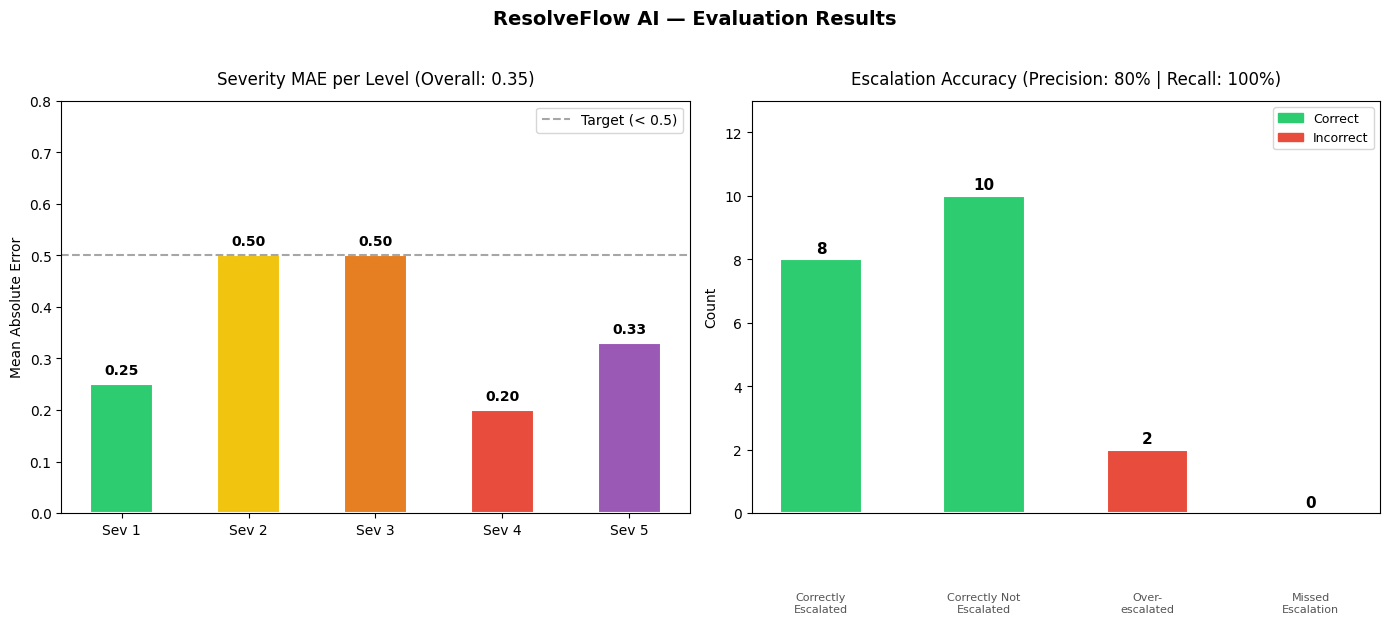

✅ Severity MAE: 0.35 | Precision: 80% | Recall: 100%


In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ResolveFlow AI — Evaluation Results', fontsize=14, fontweight='bold', y=1.02)

# Chart 1: MAE per severity level
mae_per_level = []
for level in range(1, 6):
    rows = df_eval[df_eval["tagged_severity"] == level]
    mae_per_level.append(round(rows["severity_error"].mean(), 2) if len(rows) > 0 else 0.0)

overall_mae = round(df_eval["severity_error"].mean(), 2)
colors      = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6']
bars1       = axes[0].bar(['Sev 1','Sev 2','Sev 3','Sev 4','Sev 5'],
                          mae_per_level, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title(f'Severity MAE per Level (Overall: {overall_mae})', pad=12)
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_ylim(0, max(mae_per_level + [0.5]) + 0.3)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Target (< 0.5)')
axes[0].legend()
for bar, val in zip(bars1, mae_per_level):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=10)

# Chart 2: Escalation accuracy
tp_ = len(df_eval[(df_eval["expected_escalate"]==True)  & (df_eval["actual_escalate"]==True)])
tn_ = len(df_eval[(df_eval["expected_escalate"]==False) & (df_eval["actual_escalate"]==False)])
fp_ = len(df_eval[(df_eval["expected_escalate"]==False) & (df_eval["actual_escalate"]==True)])
fn_ = len(df_eval[(df_eval["expected_escalate"]==True)  & (df_eval["actual_escalate"]==False)])
prec = round(tp_/(tp_+fp_), 2) if (tp_+fp_) > 0 else 0
rec  = round(tp_/(tp_+fn_), 2) if (tp_+fn_) > 0 else 0

values  = [tp_, tn_, fp_, fn_]
colors2 = ['#2ecc71','#2ecc71','#e74c3c','#e74c3c']
subtitles = ['Correctly\nEscalated','Correctly Not\nEscalated','Over-\nescalated','Missed\nEscalation']
bars2   = axes[1].bar(['True\nPositive','True\nNegative','False\nPositive','False\nNegative'],
                      values, color=colors2, edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title(f'Escalation Accuracy (Precision: {prec:.0%} | Recall: {rec:.0%})', pad=12)
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(values) + 3)
for bar, val, sub in zip(bars2, values, subtitles):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', fontweight='bold', fontsize=11)
    axes[1].text(bar.get_x() + bar.get_width()/2, -2.5, sub,
                 ha='center', va='top', fontsize=8, color='#555555')
axes[1].set_xticklabels([])
axes[1].tick_params(axis='x', length=0)
axes[1].legend(handles=[mpatches.Patch(color='#2ecc71', label='Correct'),
                         mpatches.Patch(color='#e74c3c', label='Incorrect')],
               loc='upper right', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Severity MAE: {overall_mae} | Precision: {prec:.0%} | Recall: {rec:.0%}")

# Section 5: Performance & Limitations

## Latency Benchmark

In [34]:
benchmarks = [
    ("Routine — Early Exit",    "What payment methods do you accept?",
     "unknown", 0,   5.0, 0),
    ("Escalated — Full Pipeline", "I was charged twice, this is absolutely unacceptable!",
     "buyer",   100, 4.5, 0),
]

print(f"  {'Scenario':<30} {'Latency':>10}  {'Path'}")
print(f"  {'-'*60}")

# Variables to store latencies for dynamic calculation
early_exit_latency = 0.0
full_pipeline_latency = 0.0

for label, query, user_type, tv, sr, pd_ in benchmarks:
    t0 = time.time()

    # Execute the pipeline
    run_pipeline(query, user_type=user_type, transaction_value=tv,
                 seller_rating=sr, past_disputes=pd_)

    t_total = round(time.time() - t0, 1)

    # Determine path and store the latency for the specific scenario
    if "Routine" in label:
        path = "Agents 1-3"
        early_exit_latency = t_total
    else:
        path = "Agents 1-5"
        full_pipeline_latency = t_total

    print(f"  {label:<30} {t_total:>9}s  {path}")

# Dynamically calculate and print the speedup percentage
if full_pipeline_latency > 0 and early_exit_latency > 0:
    speedup_percentage = ((full_pipeline_latency - early_exit_latency) / full_pipeline_latency) * 100
    print(f"\n  ⚡ Early Exit: ~{speedup_percentage:.1f}% faster for severity 1-2 (skips Agent 4 & 5)")
else:
    print("\n  ⚠️ Could not calculate speedup (need both full and early exit benchmarks).")

  Scenario                          Latency  Path
  ------------------------------------------------------------

🔍 AGENT 1: RETRIEVAL AGENT

   📄 Support docs   : 3
      [check_payment_methods] show me what payment options are accepted...
      [check_payment_methods] assistance to see ru accepted payment options...
      [check_payment_methods] check allowed payment methods...

   📋 Past cases     : 0

📊 AGENT 2: EVALUATION AGENT

   🟢 Severity    : 1/5 — ROUTINE
   😤 Sentiment   : Neutral
   📁 Issue Type  : Payment Method Inquiry
   🚨 Escalate    : False
   🛡️  Trust Safety: False
   🧠 Reasoning   : The customer is asking a basic informational question about accepted payment methods. This is a routine inquiry with no indication of frustration or urgency.

💬 AGENT 3: RESPONSE AGENT

   Tone applied : Informative and helpful (severity 1/5)

   📨 Response:
   We accept a variety of convenient payment methods to ensure a smooth transaction experience for you. You can use major credit a

## Known Limitations & Assumptions

**Assumptions:**
- Severity scoring relies on LLM judgement — no ground truth labels beyond test set
- Similarity threshold (0.81) manually tuned, not cross-validated
- Dataset uses template placeholders (`{{Order Number}}`) not real customer data

**Current Limitations:**
- English-only — no multilingual support
- MemorySaver resets on kernel restart (in-memory only)
- Escalation actions are recommendations — not connected to real ticketing systems
- No PII redaction — not suitable for real customer data
- Bitext dataset is generic — Carousell-specific domain data needed for production

**Production Roadmap:**

| Priority | Item | Rationale |
|---|---|---|
| P0 | PII Redaction | Legal compliance before real data |
| P0 | Per-agent error handling | Already implemented ✅ |
| P0 | FastAPI REST endpoint | Concurrent multi-tenant requests |
| P1 | Zendesk / Freshdesk integration | Make actions real, not recommendations |
| P1 | Human feedback loop | Improve severity scoring over time |
| P1 | Monitoring dashboard | Track escalation rate, latency, drift |
| P2 | Multilingual support | SE Asia market requirement |
| P2 | Hybrid search | Vector + keyword for better retrieval |
| P2 | Fine-tuned severity classifier | Replace LLM scorer — 10x faster, cheaper |
